# РГР: оптимізація розміщення товарів на складі

**Тема:** порівняння алгоритмів ройового інтелекту для оптимізації розміщення товарів на складі на основі прогнозування попиту.

У цій роботі я спочатку навчаю модель прогнозування попиту на товари, а потім використовую цей прогноз для оптимізації складу. Для порівняння беруться два алгоритми: **PSO** та **GWO**.

Основна ідея проста: товари з більшим попитом, великою вагою та важливими категоріальними обмеженнями потрібно розміщувати зручніше. Для цього використовується багатокритеріальна фітнес-функція.


## 1. Імпорт бібліотек і налаштування

In [1]:
from pathlib import Path
import zipfile
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")


## 2. Завантаження даних

Використовується файл `train.csv` з датасету **Store Item Demand Forecasting Challenge**.


In [2]:
zip_path = Path("demand-forecasting-kernels-only.zip")
data_dir = Path("demand_data")

data_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(data_dir)

train_path = data_dir / "train.csv"

df = pd.read_csv(train_path)

print("Розмір датасету:", df.shape)
print("Колонки датасету:", list(df.columns))

df.head()

Розмір датасету: (913000, 4)
Колонки датасету: ['date', 'store', 'item', 'sales']


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [4]:
print("Кількість магазинів:", df["store"].nunique())
print("Кількість товарів:", df["item"].nunique())
print("Період даних:", df["date"].min(), "-", df["date"].max())

df.describe()

Кількість магазинів: 10
Кількість товарів: 50
Період даних: 2013-01-01 - 2017-12-31


,store,item,sales
count,913000.0000,913000.0000,913000.0000
mean,5.5000,25.5000,52.2503
std,2.8723,14.4309,28.8011
min,1.0000,1.0000,0.0000
25%,3.0000,13.0000,30.0000
50%,5.5000,25.5000,47.0000
75%,8.0000,38.0000,70.0000
max,10.0000,50.0000,231.0000


## 3. Підготовка даних

Для роботи беремо один магазин і 20 товарів


In [5]:
df["date"] = pd.to_datetime(df["date"])

# Ознаки, які модель буде використовувати для прогнозування продажів.
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["dayofweek"] = df["date"].dt.dayofweek
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

selected_store = 1
selected_items = list(range(1, 21))

work_df = df[
    (df["store"] == selected_store) &
    (df["item"].isin(selected_items))
].copy()

# Щоб код працював швидко, використовуємо останні 2 роки даних для обраних товарів.
cutoff_date = work_df["date"].max() - pd.DateOffset(years=2)
work_df = work_df[work_df["date"] >= cutoff_date].copy()

print("Розмір робочого датасету:", work_df.shape)
print("Період робочих даних:", work_df["date"].min().date(), "-", work_df["date"].max().date())
work_df.head()

Розмір робочого датасету: (14640, 10)
Період робочих даних: 2015-12-31 - 2017-12-31


,date,store,item,sales,year,month,day,dayofweek,weekofyear,is_weekend
1094,2015-12-31,1,1,18,2015,12,31,3,53,0
1095,2016-01-01,1,1,21,2016,1,1,4,53,0
1096,2016-01-02,1,1,13,2016,1,2,5,53,1
1097,2016-01-03,1,1,12,2016,1,3,6,53,1
1098,2016-01-04,1,1,12,2016,1,4,0,1,0


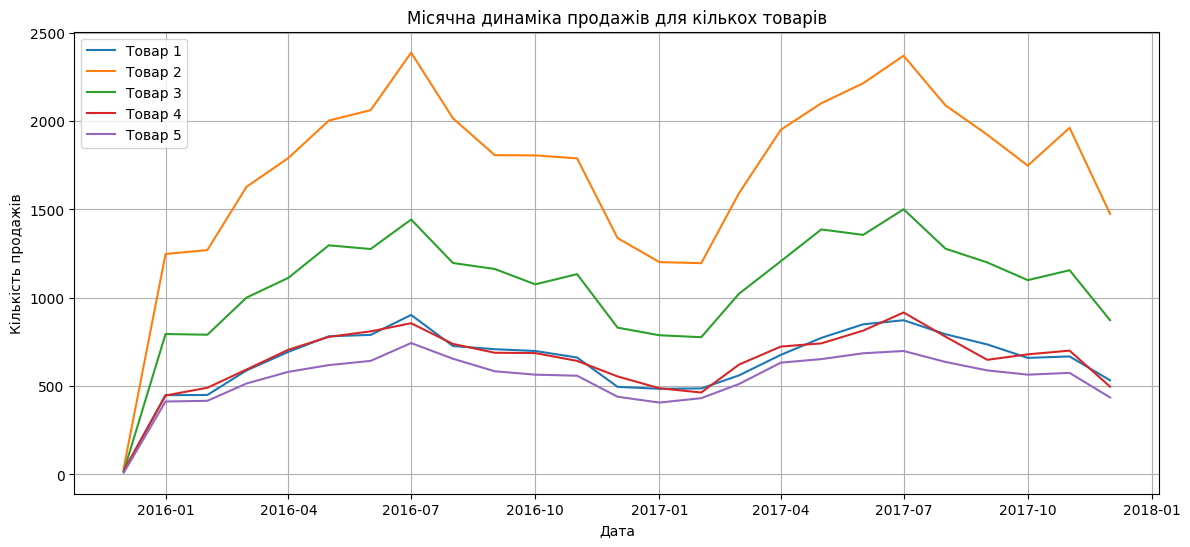

In [6]:
monthly_sales = (
    work_df
    .set_index("date")
    .groupby("item")["sales"]
    .resample("MS")
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 6))
for item in [1, 2, 3, 4, 5]:
    item_data = monthly_sales[monthly_sales["item"] == item]
    plt.plot(item_data["date"], item_data["sales"], label=f"Товар {item}")

plt.title("Місячна динаміка продажів для кількох товарів")
plt.xlabel("Дата")
plt.ylabel("Кількість продажів")
plt.legend()
plt.show()

## 4. Навчання моделі прогнозування попиту


In [7]:
features = ["store", "item", "year", "month", "day", "dayofweek", "weekofyear", "is_weekend"]
target = "sales"

X = work_df[features]
y = work_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    shuffle=True
)

model = RandomForestRegressor(
    n_estimators=60,
    max_depth=12,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start_time = time.time()
model.fit(X_train, y_train)
training_time = time.time() - start_time

pred_test = model.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)

model_metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2", "Training time, sec"],
    "value": [mae, rmse, r2, training_time]
})

model_metrics["value"] = model_metrics["value"].round(4)
model_metrics

,metric,value
0,MAE,6.0866
1,RMSE,7.8479
2,R2,0.9109
3,"Training time, sec",0.4583


## 5. Прогнозований попит для товарів

Після навчання моделі прогнозуємо продажі на наступні 90 днів. Далі цей прогноз використовується у фітнес-функції.


In [8]:
last_date = work_df["date"].max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=90, freq="D")

future_rows = []
for item in selected_items:
    for date in future_dates:
        future_rows.append({
            "date": date,
            "store": selected_store,
            "item": item,
            "year": date.year,
            "month": date.month,
            "day": date.day,
            "dayofweek": date.dayofweek,
            "weekofyear": int(date.isocalendar().week),
            "is_weekend": int(date.dayofweek in [5, 6])
        })

future_df = pd.DataFrame(future_rows)
future_df["predicted_sales"] = model.predict(future_df[features])

predicted_demand = (
    future_df
    .groupby("item")["predicted_sales"]
    .sum()
    .reset_index()
    .rename(columns={"predicted_sales": "predicted_demand"})
)

predicted_demand.round(4).head()

,item,predicted_demand
0,1,1537.7340
1,2,4082.0536
2,3,2570.6858
3,4,1545.6803
4,5,1399.5138


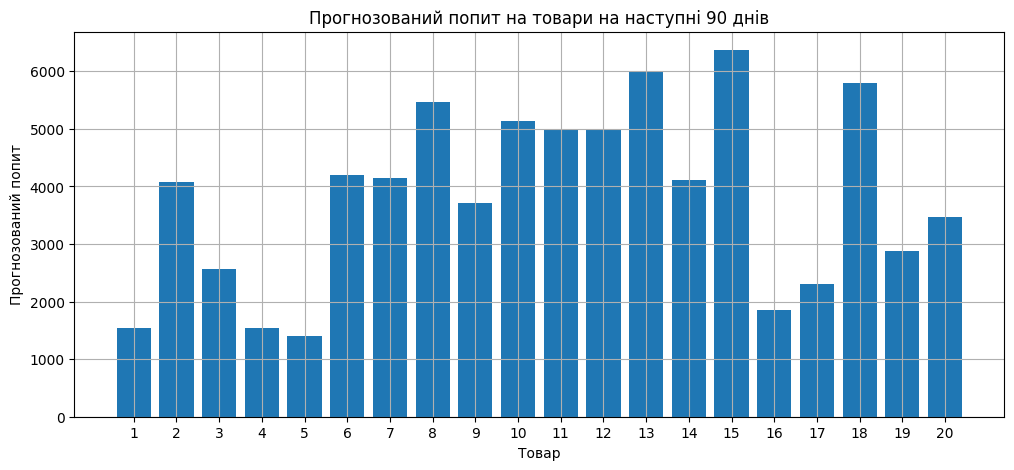

In [9]:
plt.figure(figsize=(12, 5))
plt.bar(predicted_demand["item"].astype(str), predicted_demand["predicted_demand"])
plt.title("Прогнозований попит на товари на наступні 90 днів")
plt.xlabel("Товар")
plt.ylabel("Прогнозований попит")
plt.show()

## 6. Характеристики товарів

У датасеті є продажі, але немає ваги й категорій товарів. Тому попит беремо з навченої моделі, а категорії та вагу задаємо окремо для моделювання складської задачі.


In [10]:
category_map = {
    1: "food", 2: "food", 3: "food", 4: "food", 5: "food",
    6: "chemicals", 7: "chemicals", 8: "chemicals", 9: "chemicals", 10: "chemicals",
    11: "fragile", 12: "fragile", 13: "fragile", 14: "fragile", 15: "fragile",
    16: "electronics", 17: "electronics", 18: "electronics", 19: "electronics", 20: "electronics"
}

rng = np.random.default_rng(RANDOM_STATE)

items_df = predicted_demand.copy()
items_df["category"] = items_df["item"].map(category_map)
items_df["weight"] = rng.uniform(1, 20, size=len(items_df)).round(2)

items_df["demand_norm"] = items_df["predicted_demand"] / items_df["predicted_demand"].max()
items_df["weight_norm"] = items_df["weight"] / items_df["weight"].max()

items_df.round(4)


,item,predicted_demand,category,weight,demand_norm,weight_norm
0,1,1537.7340,food,15.7100,0.2415,0.8040
1,2,4082.0536,food,9.3400,0.6410,0.4780
2,3,2570.6858,food,17.3100,0.4037,0.8859
3,4,1545.6803,food,14.2500,0.2427,0.7293
4,5,1399.5138,food,2.7900,0.2198,0.1428
5,6,4194.3291,chemicals,19.5400,0.6587,1.0000
6,7,4151.2211,chemicals,15.4600,0.6519,0.7912
7,8,5458.3712,chemicals,15.9400,0.8572,0.8158
8,9,3720.3909,chemicals,3.4300,0.5842,0.1755
9,10,5140.7561,chemicals,9.5600,0.8073,0.4893


## 7. Модель складу

Склад подано як сітку 4×5. Маємо 20 комірок і 20 товарів. Алгоритми шукають, у якій комірці краще розмістити кожен товар.


In [11]:
warehouse_rows = 4
warehouse_cols = 5
n_items = len(items_df)

locations = [(r, c) for r in range(warehouse_rows) for c in range(warehouse_cols)]
pickup_point = (0, 0)

locations_df = pd.DataFrame(locations, columns=["row", "col"])
locations_df["location_id"] = range(len(locations_df))
locations_df

,row,col,location_id
0,0,0,0
1,0,1,1
2,0,2,2
3,0,3,3
4,0,4,4
5,1,0,5
6,1,1,6
7,1,2,7
8,1,3,8
9,1,4,9


## 8. Багатокритеріальна фітнес-функція

Фітнес-функція показує, наскільки вдалим є розміщення товарів. Чим менше її значення, тим краще розміщення.

\[
F = 0.5F_{distance} + 0.2F_{category} + 0.2F_{weight} + 0.1F_{compatibility}
\]

Враховуються чотири фактори:

- відстань до зони видачі з урахуванням попиту;
- групування товарів однієї категорії;
- вага товарів;
- небажане сусідство несумісних категорій.


In [12]:
item_ids = items_df["item"].to_numpy()
categories = items_df["category"].to_numpy()
demand_norm = items_df["demand_norm"].to_numpy()
weight_norm = items_df["weight_norm"].to_numpy()

location_array = np.array(locations)
pickup_array = np.array(pickup_point)

distances_to_pickup = np.abs(location_array - pickup_array).sum(axis=1)
max_distance = distances_to_pickup.max()

incompatible_pairs = {
    ("food", "chemicals"),
    ("chemicals", "food"),
    ("fragile", "electronics"),
    ("electronics", "fragile"),
    ("fragile", "chemicals"),
    ("chemicals", "fragile")
}

def position_to_permutation(position):
    """Перетворює неперервний вектор алгоритму в перестановку товарів."""
    return np.argsort(position)


def build_item_coordinates(permutation):
    """Повертає координати кожного товару для заданої перестановки."""
    coords = np.zeros((n_items, 2), dtype=int)
    for loc_idx, item_idx in enumerate(permutation):
        coords[item_idx] = location_array[loc_idx]
    return coords


def distance_penalty(permutation):
    total = 0.0
    for loc_idx, item_idx in enumerate(permutation):
        d = distances_to_pickup[loc_idx] / max_distance
        total += d * demand_norm[item_idx]
    return total / n_items


def weight_penalty(permutation):
    total = 0.0
    for loc_idx, item_idx in enumerate(permutation):
        d = distances_to_pickup[loc_idx] / max_distance
        total += d * weight_norm[item_idx]
    return total / n_items


def category_penalty(permutation):
    coords = build_item_coordinates(permutation)
    total = 0.0
    count = 0

    for category in np.unique(categories):
        idx = np.where(categories == category)[0]
        if len(idx) < 2:
            continue

        for a in range(len(idx)):
            for b in range(a + 1, len(idx)):
                item_a = idx[a]
                item_b = idx[b]
                dist = np.abs(coords[item_a] - coords[item_b]).sum() / max_distance
                total += dist
                count += 1

    return total / count if count > 0 else 0.0


def compatibility_penalty(permutation):
    coords = build_item_coordinates(permutation)
    total = 0.0
    count = 0

    for i in range(n_items):
        for j in range(i + 1, n_items):
            dist = np.abs(coords[i] - coords[j]).sum()
            if dist == 1:
                pair = (categories[i], categories[j])
                if pair in incompatible_pairs:
                    total += 1.0
                count += 1

    return total / count if count > 0 else 0.0


def evaluate_permutation(permutation):
    f_distance = distance_penalty(permutation)
    f_category = category_penalty(permutation)
    f_weight = weight_penalty(permutation)
    f_compatibility = compatibility_penalty(permutation)

    total = (
        0.5 * f_distance +
        0.2 * f_category +
        0.2 * f_weight +
        0.1 * f_compatibility
    )

    return {
        "fitness": total,
        "distance_penalty": f_distance,
        "category_penalty": f_category,
        "weight_penalty": f_weight,
        "compatibility_penalty": f_compatibility
    }


def fitness_from_position(position):
    permutation = position_to_permutation(position)
    return evaluate_permutation(permutation)["fitness"]

In [13]:
initial_permutation = np.arange(n_items)
rng.shuffle(initial_permutation)

initial_metrics = evaluate_permutation(initial_permutation)
pd.DataFrame([initial_metrics]).round(4)


,fitness,distance_penalty,category_penalty,weight_penalty,compatibility_penalty
0,0.3288,0.2780,0.3857,0.3213,0.4839


## 9. Алгоритм PSO

PSO працює з числовими векторами. Щоб застосувати його до задачі розміщення, вектор перетворюється у перестановку товарів через `argsort`.


In [14]:
def run_pso(fitness_func, dimensions, n_particles=30, n_iterations=80, random_state=42):
    rng = np.random.default_rng(random_state)

    positions = rng.random((n_particles, dimensions))
    velocities = rng.uniform(-0.1, 0.1, size=(n_particles, dimensions))

    personal_best_positions = positions.copy()
    personal_best_scores = np.array([fitness_func(pos) for pos in positions])

    best_idx = np.argmin(personal_best_scores)
    global_best_position = personal_best_positions[best_idx].copy()
    global_best_score = personal_best_scores[best_idx]

    history = []

    w = 0.72
    c1 = 1.49
    c2 = 1.49

    for _ in range(n_iterations):
        r1 = rng.random((n_particles, dimensions))
        r2 = rng.random((n_particles, dimensions))

        velocities = (
            w * velocities +
            c1 * r1 * (personal_best_positions - positions) +
            c2 * r2 * (global_best_position - positions)
        )

        positions = positions + velocities
        positions = np.clip(positions, 0, 1)

        scores = np.array([fitness_func(pos) for pos in positions])

        improved = scores < personal_best_scores
        personal_best_positions[improved] = positions[improved]
        personal_best_scores[improved] = scores[improved]

        best_idx = np.argmin(personal_best_scores)
        if personal_best_scores[best_idx] < global_best_score:
            global_best_score = personal_best_scores[best_idx]
            global_best_position = personal_best_positions[best_idx].copy()

        history.append(global_best_score)

    best_permutation = position_to_permutation(global_best_position)

    return {
        "best_position": global_best_position,
        "best_permutation": best_permutation,
        "best_score": global_best_score,
        "history": history
    }

## 10. Алгоритм GWO


In [15]:
def run_gwo(fitness_func, dimensions, n_wolves=30, n_iterations=80, random_state=42):
    rng = np.random.default_rng(random_state)

    positions = rng.random((n_wolves, dimensions))
    scores = np.array([fitness_func(pos) for pos in positions])

    order = np.argsort(scores)
    alpha_pos = positions[order[0]].copy()
    beta_pos = positions[order[1]].copy()
    delta_pos = positions[order[2]].copy()
    alpha_score = scores[order[0]]

    history = []

    for iteration in range(n_iterations):
        a = 2 - 2 * iteration / n_iterations

        for i in range(n_wolves):
            r1 = rng.random(dimensions)
            r2 = rng.random(dimensions)
            A1 = 2 * a * r1 - a
            C1 = 2 * r2
            D_alpha = np.abs(C1 * alpha_pos - positions[i])
            X1 = alpha_pos - A1 * D_alpha

            r1 = rng.random(dimensions)
            r2 = rng.random(dimensions)
            A2 = 2 * a * r1 - a
            C2 = 2 * r2
            D_beta = np.abs(C2 * beta_pos - positions[i])
            X2 = beta_pos - A2 * D_beta

            r1 = rng.random(dimensions)
            r2 = rng.random(dimensions)
            A3 = 2 * a * r1 - a
            C3 = 2 * r2
            D_delta = np.abs(C3 * delta_pos - positions[i])
            X3 = delta_pos - A3 * D_delta

            positions[i] = (X1 + X2 + X3) / 3
            positions[i] = np.clip(positions[i], 0, 1)

        scores = np.array([fitness_func(pos) for pos in positions])
        order = np.argsort(scores)

        alpha_pos = positions[order[0]].copy()
        beta_pos = positions[order[1]].copy()
        delta_pos = positions[order[2]].copy()
        alpha_score = scores[order[0]]

        history.append(alpha_score)

    best_permutation = position_to_permutation(alpha_pos)

    return {
        "best_position": alpha_pos,
        "best_permutation": best_permutation,
        "best_score": alpha_score,
        "history": history
    }

## 11. Запуск оптимізації

In [16]:
start_time = time.time()
pso_result = run_pso(
    fitness_from_position,
    dimensions=n_items,
    n_particles=30,
    n_iterations=80,
    random_state=RANDOM_STATE
)
pso_time = time.time() - start_time

start_time = time.time()
gwo_result = run_gwo(
    fitness_from_position,
    dimensions=n_items,
    n_wolves=30,
    n_iterations=80,
    random_state=RANDOM_STATE
)
gwo_time = time.time() - start_time

print(f"PSO best fitness: {pso_result["best_score"]:.4f}")
print(f"GWO best fitness: {gwo_result["best_score"]:.4f}")
print(f"PSO time: {pso_time:.4f} sec")
print(f"GWO time: {gwo_time:.4f} sec")

PSO best fitness: 0.2507
GWO best fitness: 0.2577
PSO time: 6.2337 sec
GWO time: 6.6327 sec


## 12. Порівняння результатів

In [17]:
def metrics_row(method_name, permutation, runtime):
    metrics = evaluate_permutation(permutation)
    return {
        "method": method_name,
        "fitness": metrics["fitness"],
        "distance_penalty": metrics["distance_penalty"],
        "category_penalty": metrics["category_penalty"],
        "weight_penalty": metrics["weight_penalty"],
        "compatibility_penalty": metrics["compatibility_penalty"],
        "time_sec": runtime
    }

results_df = pd.DataFrame([
    metrics_row("Початкове розміщення", initial_permutation, 0),
    metrics_row("PSO", pso_result["best_permutation"], pso_time),
    metrics_row("GWO", gwo_result["best_permutation"], gwo_time)
])

results_df.round(4)

,method,fitness,distance_penalty,category_penalty,weight_penalty,compatibility_penalty,time_sec
0,Початкове розміщення,0.3288,0.2780,0.3857,0.3213,0.4839,0.0000
1,PSO,0.2507,0.2596,0.2500,0.2740,0.1613,6.2337
2,GWO,0.2577,0.2520,0.2857,0.2762,0.1935,6.6327


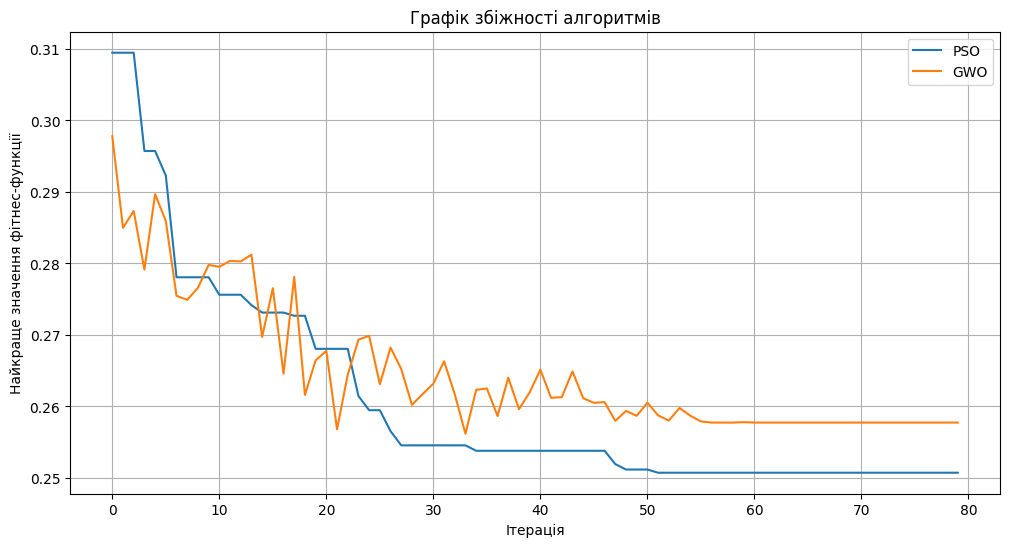

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(pso_result["history"], label="PSO")
plt.plot(gwo_result["history"], label="GWO")
plt.title("Графік збіжності алгоритмів")
plt.xlabel("Ітерація")
plt.ylabel("Найкраще значення фітнес-функції")
plt.legend()
plt.show()

## 13. Візуалізація розміщення товарів на складі

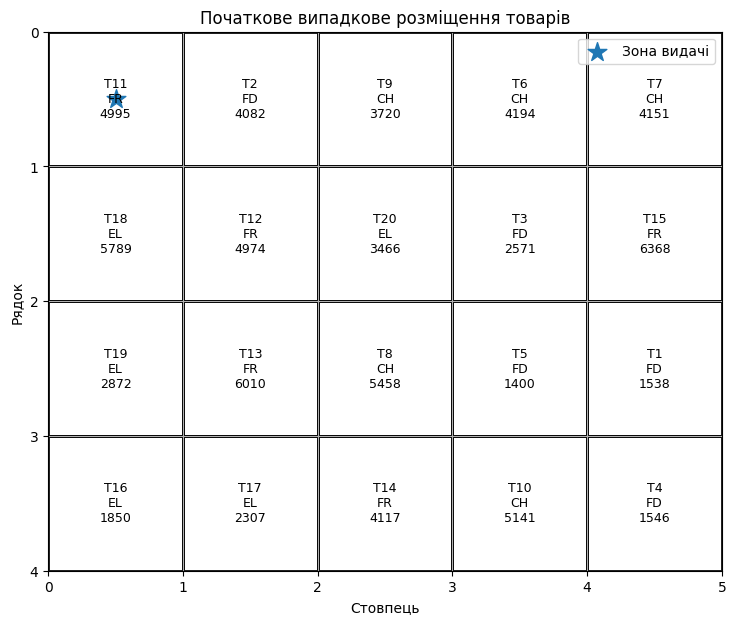

In [19]:
category_short = {
    "food": "FD",
    "chemicals": "CH",
    "fragile": "FR",
    "electronics": "EL"
}


def layout_dataframe(permutation):
    rows = []
    for loc_idx, item_idx in enumerate(permutation):
        item_id = item_ids[item_idx]
        category = categories[item_idx]
        demand = items_df.loc[item_idx, "predicted_demand"]
        weight = items_df.loc[item_idx, "weight"]
        row, col = locations[loc_idx]
        rows.append({
            "location_id": loc_idx,
            "row": row,
            "col": col,
            "item": item_id,
            "category": category,
            "predicted_demand": demand,
            "weight": weight
        })
    return pd.DataFrame(rows)


def plot_layout(permutation, title):
    layout = layout_dataframe(permutation)

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.set_xlim(0, warehouse_cols)
    ax.set_ylim(0, warehouse_rows)
    ax.set_aspect("equal")
    ax.invert_yaxis()

    for _, row in layout.iterrows():
        r = int(row["row"])
        c = int(row["col"])
        item = int(row["item"])
        category = row["category"]
        demand = row["predicted_demand"]

        rect = plt.Rectangle((c, r), 1, 1, fill=False, linewidth=2)
        ax.add_patch(rect)
        text = f"T{item}\n{category_short[category]}\n{demand:.0f}"
        ax.text(c + 0.5, r + 0.5, text, ha="center", va="center", fontsize=9)

    ax.scatter([pickup_point[1] + 0.5], [pickup_point[0] + 0.5], s=200, marker="*", label="Зона видачі")
    ax.set_xticks(np.arange(0, warehouse_cols + 1, 1))
    ax.set_yticks(np.arange(0, warehouse_rows + 1, 1))
    ax.set_title(title)
    ax.set_xlabel("Стовпець")
    ax.set_ylabel("Рядок")
    ax.legend(loc="upper right")
    plt.show()

plot_layout(initial_permutation, "Початкове випадкове розміщення товарів")

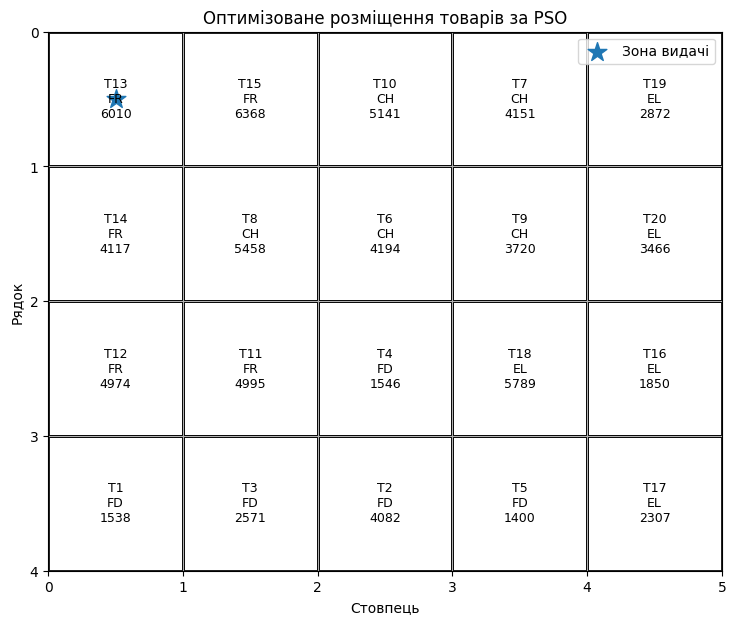

In [20]:
plot_layout(pso_result["best_permutation"], "Оптимізоване розміщення товарів за PSO")

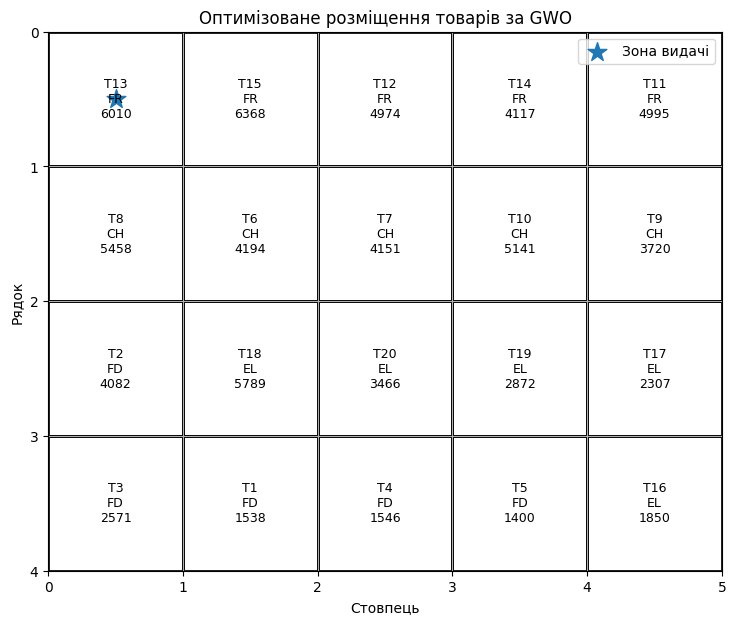

In [21]:
plot_layout(gwo_result["best_permutation"], "Оптимізоване розміщення товарів за GWO")

## 14. Таблиці оптимізованого розміщення

In [22]:
pso_layout = layout_dataframe(pso_result["best_permutation"])
gwo_layout = layout_dataframe(gwo_result["best_permutation"])

pso_layout.round(4).head(20)

,location_id,row,col,item,category,predicted_demand,weight
0,0,0,0,13,fragile,6010.1016,13.2300
1,1,0,1,15,fragile,6368.0341,9.4200
2,2,0,2,10,chemicals,5140.7561,9.5600
3,3,0,3,7,chemicals,4151.2211,15.4600
4,4,0,4,19,electronics,2872.3749,16.7200
5,5,1,0,14,fragile,4117.0826,16.6300
6,6,1,1,8,chemicals,5458.3712,15.9400
7,7,1,2,6,chemicals,4194.3291,19.5400
8,8,1,3,9,chemicals,3720.3909,3.4300
9,9,1,4,20,electronics,3466.4237,13.0000


In [23]:
gwo_layout.round(4).head(20)

,location_id,row,col,item,category,predicted_demand,weight
0,0,0,0,13,fragile,6010.1016,13.2300
1,1,0,1,15,fragile,6368.0341,9.4200
2,2,0,2,12,fragile,4974.1791,18.6100
3,3,0,3,14,fragile,4117.0826,16.6300
4,4,0,4,11,fragile,4994.7808,8.0500
5,5,1,0,8,chemicals,5458.3712,15.9400
6,6,1,1,6,chemicals,4194.3291,19.5400
7,7,1,2,7,chemicals,4151.2211,15.4600
8,8,1,3,10,chemicals,5140.7561,9.5600
9,9,1,4,9,chemicals,3720.3909,3.4300


## 15. Короткий підсумок


In [24]:
best_method = results_df.loc[results_df["fitness"].idxmin(), "method"]
initial_fitness = results_df.loc[results_df["method"] == "Початкове розміщення", "fitness"].iloc[0]
best_fitness = results_df["fitness"].min()
improvement = (initial_fitness - best_fitness) / initial_fitness * 100

print("Метрики моделі прогнозування попиту:")
print(model_metrics.to_string(index=False))
print()
print("Порівняння розміщення товарів:")
print(results_df.round(4).to_string(index=False))
print()
print(f"Найкращий метод за значенням фітнес-функції: {best_method}")
print(f"Покращення порівняно з початковим розміщенням: {improvement:.4f}%")

Метрики моделі прогнозування попиту:
            metric  value
               MAE 6.0866
              RMSE 7.8479
                R2 0.9109
Training time, sec 0.4583

Порівняння розміщення товарів:
              method  fitness  distance_penalty  category_penalty  weight_penalty  compatibility_penalty  time_sec
Початкове розміщення   0.3288            0.2780            0.3857          0.3213                 0.4839    0.0000
                 PSO   0.2507            0.2596            0.2500          0.2740                 0.1613    6.2337
                 GWO   0.2577            0.2520            0.2857          0.2762                 0.1935    6.6327

Найкращий метод за значенням фітнес-функції: PSO
Покращення порівняно з початковим розміщенням: 23.7403%
